<a href="https://colab.research.google.com/github/avram4uk/coursework/blob/main/%D0%B3%D0%BB%D0%B0%D0%B2%D0%B0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import pandas as pd
from pathlib import Path

# Укажите путь к корневой папке датасета после распаковки
DATASET_PATH = Path("/content/drive/MyDrive/датасет")

def analyze_dataset_structure(dataset_path):
    """
    Анализирует структуру датасета, выводя общее количество изображений,
    список классов и количество элементов в каждом классе.
    """
    print("=" * 60)
    print("АНАЛИЗ ДАТАСЕТА: Gender Detection & Classification")
    print("=" * 60)

    # Словарь для хранения количества изображений по классам
    class_counts = {"women": 0, "men": 0}
    total_images = 0

    # Рекурсивный обход всех подпапок
    for root, dirs, files in os.walk(dataset_path):
        # Проверяем, находится ли текущая папка внутри папки класса
        # Папки классов могут быть: 'women', 'men' (игнорируем регистр)
        current_folder = os.path.basename(root).lower()

        if current_folder in class_counts:
            # Считаем только файлы изображений (распространённые расширения)
            image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
            image_files = [
                f for f in files
                if Path(f).suffix.lower() in image_extensions
            ]
            count = len(image_files)
            class_counts[current_folder] += count
            total_images += count

            # Выводим информацию по каждой найденной папке
            rel_path = os.path.relpath(root, dataset_path)
            if rel_path == '.':
                rel_path = current_folder
            print(f" Папка: {rel_path} -> {count} изображений")

    print("\n" + "=" * 60)
    print("ИТОГОВАЯ СТАТИСТИКА")
    print("=" * 60)
    print(f" Общее количество изображений в датасете: {total_images}")
    print(f"\n  Классы и количество элементов:")
    for class_name, count in class_counts.items():
        print(f"   - {class_name.capitalize()} ({class_name}): {count} изображений")

    # Дополнительно: анализ через CSV-файл (если он существует)
    csv_path = dataset_path / "gender_detection.csv"
    if csv_path.exists():
        print("\n" + "-" * 60)
        print("ПРОВЕРКА ПО CSV-ФАЙЛУ")
        print("-" * 60)
        df = pd.read_csv(csv_path)

        # Проверяем наличие колонки с метками пола
        if 'gender' in df.columns:
            csv_counts = df['gender'].value_counts()
            print("Статистика из CSV-файла:")
            for gender, count in csv_counts.items():
                print(f"   - {gender}: {count} записей")

    return class_counts, total_images

class_counts, total = analyze_dataset_structure(DATASET_PATH)

АНАЛИЗ ДАТАСЕТА: Gender Detection & Classification
 Папка: train/women -> 110 изображений
 Папка: train/men -> 110 изображений
 Папка: test/women -> 40 изображений
 Папка: test/men -> 40 изображений

ИТОГОВАЯ СТАТИСТИКА
 Общее количество изображений в датасете: 300

  Классы и количество элементов:
   - Women (women): 150 изображений
   - Men (men): 150 изображений

------------------------------------------------------------
ПРОВЕРКА ПО CSV-ФАЙЛУ
------------------------------------------------------------
Статистика из CSV-файла:
   - woman: 150 записей
   - man: 150 записей


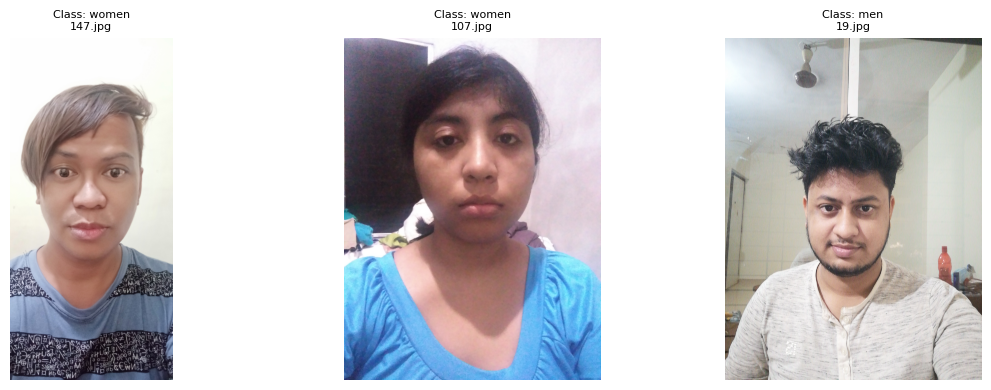

Всего изображений: 300
1. /content/drive/MyDrive/датасет/test/women/147.jpg (Class: women)
2. /content/drive/MyDrive/датасет/train/women/107.jpg (Class: women)
3. /content/drive/MyDrive/датасет/train/men/19.jpg (Class: men)


In [6]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Собираем все изображения
images = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
    images.extend(DATASET_PATH.rglob(ext))

# Выбираем 3 случайных изображения
selected = random.sample(images, min(3, len(images)))

# Отображаем
fig, axes = plt.subplots(1, len(selected), figsize=(12, 4))
for i, img_path in enumerate(selected):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Class: {img_path.parent.name}\n{img_path.name}", fontsize=8)

plt.tight_layout()
plt.show()

# Выводим информацию
print(f"Всего изображений: {len(images)}")
for i, img_path in enumerate(selected, 1):
    print(f"{i}. {img_path} (Class: {img_path.parent.name})")

In [7]:
import hashlib
import os
from pathlib import Path
from collections import defaultdict

DATASET_PATH = Path("/content/drive/MyDrive/датасет")

def find_exact_duplicates(dataset_path):
    """
    Находит точные дубликаты изображений (100% идентичные файлы).
    Использует MD5 хэширование.
    """

    print("=" * 60)
    print("ПОИСК ТОЧНЫХ ДУБЛИКАТОВ (MD5)")
    print("=" * 60)

    # Словарь для хранения хэшей и путей к файлам
    hash_map = defaultdict(list)

    # Проходим по всем файлам
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
    total_files = 0

    print(" Вычисление MD5 хэшей...")

    for file_path in dataset_path.rglob('*'):
        if file_path.suffix.lower() in image_extensions:
            total_files += 1

            # Вычисляем MD5 хэш файла
            with open(file_path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            hash_map[file_hash].append(str(file_path))

            # Прогресс (каждые 100 файлов)
            if total_files % 100 == 0:
                print(f"   Обработано файлов: {total_files}")

    # Находим дубликаты
    duplicates = {h: paths for h, paths in hash_map.items() if len(paths) > 1}

    # Подсчитываем статистику
    total_duplicate_files = sum(len(paths) for paths in duplicates.values())
    total_duplicate_groups = len(duplicates)

    print("\n" + "=" * 60)
    print("РЕЗУЛЬТАТЫ ПОИСКА ТОЧНЫХ ДУБЛИКАТОВ")
    print("=" * 60)
    print(f" Всего обработано файлов: {total_files}")
    print(f" Найдено групп дубликатов: {total_duplicate_groups}")
    print(f"  Всего дублированных файлов: {total_duplicate_files - total_duplicate_groups}")

    # Выводим примеры
    if duplicates:
        print("\n ПРИМЕРЫ ДУБЛИКАТОВ:")
        for i, (hash_val, paths) in enumerate(duplicates.items()):
            if i >= 5:
                break
            print(f"\n  Группа {i+1} (хэш: {hash_val[:16]}...):")
            for path in paths[:3]:
                print(f"    → {path}")

    return duplicates

# Запуск поиска
if __name__ == "__main__":
    if not DATASET_PATH.exists():
        print(f" Ошибка: Путь '{DATASET_PATH}' не существует.")
    else:
        exact_duplicates = find_exact_duplicates(DATASET_PATH)

ПОИСК ТОЧНЫХ ДУБЛИКАТОВ (MD5)
 Вычисление MD5 хэшей...
   Обработано файлов: 100
   Обработано файлов: 200
   Обработано файлов: 300

РЕЗУЛЬТАТЫ ПОИСКА ТОЧНЫХ ДУБЛИКАТОВ
 Всего обработано файлов: 300
 Найдено групп дубликатов: 0
  Всего дублированных файлов: 0


In [8]:
import cv2
import os
from pathlib import Path
from tqdm import tqdm

DATASET_PATH = Path("/content/gender_detection.csv")
TARGET_SIZE = (512, 512)

def resize_dataset_inplace(dataset_path, target_size=(512, 512)):
    """
    Изменяет размер всех изображений на месте (перезаписывает исходные).

     ВНИМАНИЕ: Исходные изображения будут перезаписаны!
    """

    print("=" * 60)
    print("  ИЗМЕНЕНИЕ РАЗМЕРА НА МЕСТЕ (ПЕРЕЗАПИСЬ)")
    print("=" * 60)

    # Подтверждение действия
    response = input("Вы уверены? Это действие перезапишет исходные изображения! (yes/no): ")
    if response.lower() != 'yes':
        print(" Операция отменена.")
        return

    # Собираем все изображения
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
    images = []
    for ext in image_extensions:
        images.extend(dataset_path.rglob(f'*{ext}'))
        images.extend(dataset_path.rglob(f'*{ext.upper()}'))

    print(f" Найдено изображений: {len(images)}")
    print(" Изменение размера...")

    success_count = 0
    for img_path in tqdm(images, desc="Обработка", unit="изобр"):
        try:
            img = cv2.imread(str(img_path))
            if img is not None:
                resized = cv2.resize(img, target_size, interpolation=cv2.INTER_LANCZOS4)
                cv2.imwrite(str(img_path), resized)
                success_count += 1
        except Exception as e:
            print(f" Ошибка: {img_path} - {e}")

    print(f"\n Обработано: {success_count} из {len(images)}")

# resize_dataset_inplace(DATASET_PATH, TARGET_SIZE)